In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Dataset

In [2]:
df = pd.read_csv(
    "../data/raw/applications.csv",
    low_memory=False
)

print(df.shape)

df.head()

(239664, 30)


,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


### 2. Overview Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239664 entries, 0 to 239663
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   appid                  239664 non-null  int64  
 1   name                   239660 non-null  str    
 2   type                   236997 non-null  str    
 3   is_free                239664 non-null  bool   
 4   release_date           202809 non-null  str    
 5   required_age           239664 non-null  str    
 6   short_description      224171 non-null  str    
 7   supported_languages    222006 non-null  str    
 8   header_image           239664 non-null  str    
 9   background             239664 non-null  str    
 10  metacritic_score       5299 non-null    float64
 11  recommendations_total  22560 non-null   float64
 12  mat_supports_windows   239664 non-null  bool   
 13  mat_supports_mac       239664 non-null  bool   
 14  mat_supports_linux     239664 non-null  bool   

### 3. Missing Values Analysis

In [4]:
missing = df.isnull().sum()

missing_percent = (
    missing / len(df)
) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
})

missing_df = missing_df.sort_values(
    by='Missing %',
    ascending=False
)

missing_df.head(15)

,Missing Count,Missing %
metacritic_score,234365,97.788988
recommendations_total,217104,90.586822
mat_achievement_count,178263,74.380383
mat_pc_graphics_rec,147617,61.593314
mat_pc_memory_rec,142839,59.599690
mat_pc_processor_rec,142628,59.511650
mat_pc_os_rec,137774,57.486314
mat_final_price,94741,39.530760
mat_initial_price,94741,39.530760
mat_discount_percent,94741,39.530760


### 4. Visualization Missing Data

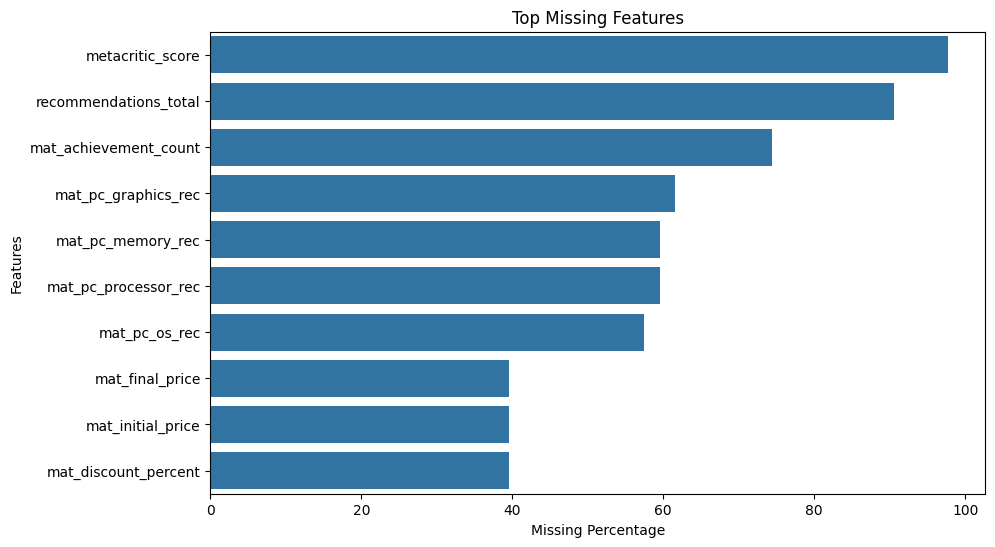

In [5]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_df.head(10)['Missing %'],
    y=missing_df.head(10).index
)

plt.title("Top Missing Features")
plt.xlabel("Missing Percentage")
plt.ylabel("Features")

plt.show()

### 5. Bias Analysis
- Ví dụ:

    - Linux games ít hơn Windows
    - Có thể gây bias model

In [6]:
platform_counts = {
    'Windows': df['mat_supports_windows'].sum(),
    'Mac': df['mat_supports_mac'].sum(),
    'Linux': df['mat_supports_linux'].sum()
}

platform_df = pd.DataFrame({
    'Platform': platform_counts.keys(),
    'Count': platform_counts.values()
})

platform_df

,Platform,Count
0,Windows,239658
1,Mac,239392
2,Linux,239364


### 6. Visualization Bias

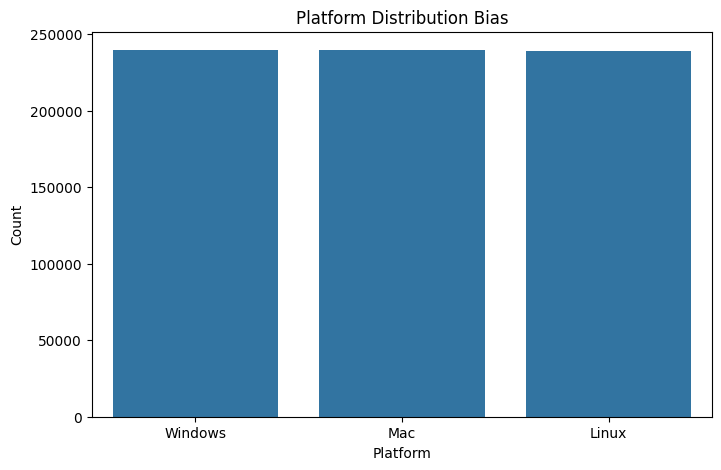

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x='Platform',
    y='Count',
    data=platform_df
)

plt.title("Platform Distribution Bias")

plt.show()

### 7. Phân tích về đạo đức AI

In [8]:
print("""
CÁC VẤN ĐỀ ĐẠO ĐỨC ĐƯỢC NHẬN DIỆN

1. MẤT CÂN BẰNG DỮ LIỆU
- Các game hỗ trợ Windows chiếm phần lớn dataset.
- Game hỗ trợ Linux và Mac xuất hiện ít hơn.
- Điều này có thể khiến mô hình học máy bị thiên lệch.

2. DỮ LIỆU THIẾU
- Nhiều thuộc tính có tỷ lệ missing value rất cao.
- Một số game không có điểm Metacritic hoặc số lượng recommendations.
- Điều này ảnh hưởng đến chất lượng mô hình.

3. THIÊN LỆCH ĐỘ PHỔ BIẾN
- Các game nổi tiếng thường nhận được nhiều đánh giá hơn.
- Các game indie nhỏ có thể bị mô hình đánh giá thấp.

4. RỦI RO TỪ HỆ THỐNG TỰ ĐỘNG
- Hệ thống recommendation có thể ưu tiên các game đã nổi tiếng.
- Game mới sẽ khó được đề xuất hơn.

5. QUYỀN RIÊNG TƯ DỮ LIỆU
- Dataset không chứa dữ liệu cá nhân nhạy cảm của người dùng.
- Rủi ro về quyền riêng tư tương đối thấp.
""")


CÁC VẤN ĐỀ ĐẠO ĐỨC ĐƯỢC NHẬN DIỆN

1. MẤT CÂN BẰNG DỮ LIỆU
- Các game hỗ trợ Windows chiếm phần lớn dataset.
- Game hỗ trợ Linux và Mac xuất hiện ít hơn.
- Điều này có thể khiến mô hình học máy bị thiên lệch.

2. DỮ LIỆU THIẾU
- Nhiều thuộc tính có tỷ lệ missing value rất cao.
- Một số game không có điểm Metacritic hoặc số lượng recommendations.
- Điều này ảnh hưởng đến chất lượng mô hình.

3. THIÊN LỆCH ĐỘ PHỔ BIẾN
- Các game nổi tiếng thường nhận được nhiều đánh giá hơn.
- Các game indie nhỏ có thể bị mô hình đánh giá thấp.

4. RỦI RO TỪ HỆ THỐNG TỰ ĐỘNG
- Hệ thống recommendation có thể ưu tiên các game đã nổi tiếng.
- Game mới sẽ khó được đề xuất hơn.

5. QUYỀN RIÊNG TƯ DỮ LIỆU
- Dataset không chứa dữ liệu cá nhân nhạy cảm của người dùng.
- Rủi ro về quyền riêng tư tương đối thấp.



### 8. Fairness & Responsible AI

In [9]:
print("""
TÍNH CÔNG BẰNG VÀ AI CÓ TRÁCH NHIỆM

- Hệ thống machine learning không nên chỉ ưu tiên
  các game phổ biến.

- Cần kiểm tra và giảm thiểu platform bias
  trong quá trình huấn luyện mô hình.

- Dataset cân bằng sẽ giúp mô hình công bằng hơn.

- Các phương pháp giải thích mô hình giúp tăng:
    + tính minh bạch
    + khả năng giải thích
    + độ tin cậy của AI

- Một hệ thống AI có trách nhiệm cần đảm bảo:
    + công bằng
    + minh bạch
    + trách nhiệm giải trình
    + chất lượng dữ liệu
""")


TÍNH CÔNG BẰNG VÀ AI CÓ TRÁCH NHIỆM

- Hệ thống machine learning không nên chỉ ưu tiên
  các game phổ biến.

- Cần kiểm tra và giảm thiểu platform bias
  trong quá trình huấn luyện mô hình.

- Dataset cân bằng sẽ giúp mô hình công bằng hơn.

- Các phương pháp giải thích mô hình giúp tăng:
    + tính minh bạch
    + khả năng giải thích
    + độ tin cậy của AI

- Một hệ thống AI có trách nhiệm cần đảm bảo:
    + công bằng
    + minh bạch
    + trách nhiệm giải trình
    + chất lượng dữ liệu



### 9. Hạn chế của Project

In [10]:
print("""
HẠN CHẾ CỦA PROJECT

1. Dataset chứa nhiều dữ liệu thiếu.

2. Một số feature engineering còn đơn giản.

3. Các đặc trưng dạng text chưa được xử lý chuyên sâu.

4. Dataset chưa phản ánh đầy đủ toàn bộ hệ sinh thái Steam.

5. Giới hạn tài nguyên tính toán nên chưa sử dụng
   các mô hình deep learning lớn.
""")


HẠN CHẾ CỦA PROJECT

1. Dataset chứa nhiều dữ liệu thiếu.

2. Một số feature engineering còn đơn giản.

3. Các đặc trưng dạng text chưa được xử lý chuyên sâu.

4. Dataset chưa phản ánh đầy đủ toàn bộ hệ sinh thái Steam.

5. Giới hạn tài nguyên tính toán nên chưa sử dụng
   các mô hình deep learning lớn.



### Kết luận tổng thể

In [11]:
print("""
KẾT LUẬN TỔNG THỂ

- Bộ dữ liệu Steam Games cung cấp nhiều thông tin hữu ích
  phục vụ cho bài toán machine learning và phân tích dữ liệu.

- Tuy nhiên, dataset vẫn tồn tại nhiều vấn đề như:
    + dữ liệu thiếu
    + mất cân bằng nền tảng
    + thiên lệch độ phổ biến

- Việc phân tích đạo đức AI giúp:
    + tăng tính minh bạch
    + cải thiện độ tin cậy
    + đảm bảo tính công bằng của mô hình

- Responsible AI là yếu tố quan trọng trong
  các hệ thống machine learning hiện đại.
""")


KẾT LUẬN TỔNG THỂ

- Bộ dữ liệu Steam Games cung cấp nhiều thông tin hữu ích
  phục vụ cho bài toán machine learning và phân tích dữ liệu.

- Tuy nhiên, dataset vẫn tồn tại nhiều vấn đề như:
    + dữ liệu thiếu
    + mất cân bằng nền tảng
    + thiên lệch độ phổ biến

- Việc phân tích đạo đức AI giúp:
    + tăng tính minh bạch
    + cải thiện độ tin cậy
    + đảm bảo tính công bằng của mô hình

- Responsible AI là yếu tố quan trọng trong
  các hệ thống machine learning hiện đại.

